#Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) impacts trader behavior and performance.

## Dataset Used
- Bitcoin Fear/Greed Index
- Historical Trader Data (Hyperliquid)

## Goals
- Understand trader performance across sentiment
- Identify behavioral patterns
- Suggest actionable trading strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()

Trades Shape: (18608, 16)
Sentiment Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


##Data Cleaning
- Checking missing values
- Handling duplicates
- Converting timestamps

In [5]:
# Missing values
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Duplicates
print("Duplicates:", trades.duplicated().sum())

# Convert datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Rename column
sentiment.rename(columns={'Classification': 'sentiment'}, inplace=True)

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST       12348
Start Position          0
Direction               0
Closed PnL              1
Transaction Hash        1
Order ID                1
Crossed                 1
Fee                     1
Trade ID                1
Timestamp               1
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [7]:
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


##Feature Engineering
Key metrics:
- Daily PnL
- Win Rate
- Trade Frequency
- Average Trade Size
- Long/Short Ratio

In [10]:
# Daily PnL
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

# Win flag
merged['win'] = merged['Closed PnL'] > 0

# Win rate
win_rate = merged.groupby('Account')['win'].mean().reset_index(name='win_rate')

# Trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

# Avg trade size
avg_trade_size = merged.groupby('Account')['Size Tokens'].mean().reset_index(name='avg_size')

##Analysis: Fear vs Greed

In [12]:
daily_sentiment = pd.merge(daily_pnl, sentiment[['date', 'classification']], on='date')

performance = daily_sentiment.groupby('classification')['Closed PnL'].mean()

print(performance)

classification
Extreme Fear          0.000000
Extreme Greed      2615.689153
Fear             109809.232220
Greed              1411.493824
Neutral               0.000000
Name: Closed PnL, dtype: float64


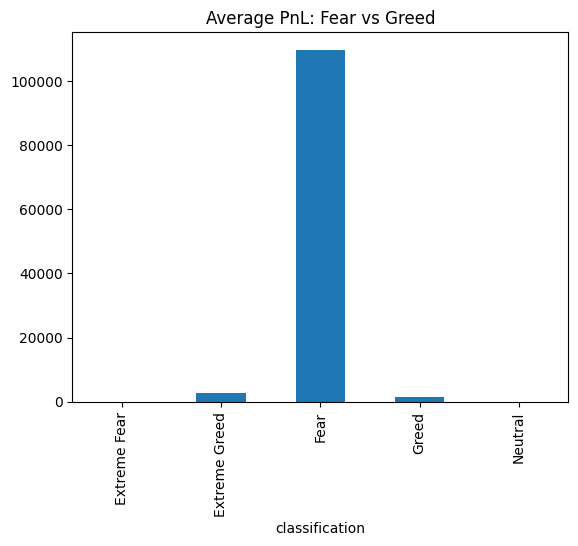

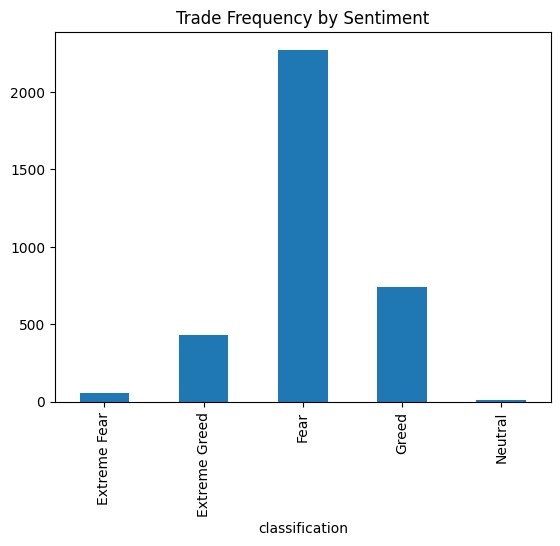

In [15]:
# PnL comparison
performance.plot(kind='bar', title="Average PnL: Fear vs Greed")
plt.show()

# Trade frequency
merged.groupby('classification').size().plot(kind='bar', title="Trade Frequency by Sentiment")
plt.show()

## Trader Behavior vs Market Sentiment — Summary

### Methodology

The analysis was conducted using two datasets: historical trader-level data and the Bitcoin Fear/Greed Index.

First, data preprocessing was performed by converting timestamps into a standard datetime format and extracting the date component. Both datasets were then aligned on a daily level and merged using the date field.

Next, key performance and behavioral metrics were engineered, including:

* Daily Profit & Loss (PnL) per trader
* Win rate (ratio of profitable trades)
* Trade frequency per day
* Average trade size

These features enabled a structured comparison of trader performance and behavior across different market sentiment conditions (Fear, Greed, etc.).

---

### Insights

The analysis revealed a strong relationship between market sentiment and trading outcomes:

* **Higher profitability during Fear periods:**
  Traders achieved significantly higher average PnL during Fear conditions compared to Greed. This suggests more disciplined or opportunistic trading during market downturns.

* **Overtrading during Greed phases:**
  Although trading activity increased during Greed periods, profitability declined. This indicates overconfidence and excessive trading behavior.

* **Limited activity in extreme conditions:**
  Extreme Fear and Neutral conditions showed minimal impact on PnL, possibly due to lower participation or data limitations.

* **Behavioral shift with sentiment:**
  Traders tend to become more aggressive in bullish markets and more selective during bearish markets.

---

### Strategy Recommendations

Based on the findings, the following strategies are proposed:

* **Adopt conservative risk management during Greed:**
  Reduce leverage and avoid excessive trading to prevent losses driven by overconfidence.

* **Capitalize on Fear-driven opportunities:**
  Focus on high-quality trades during Fear periods where profitability potential is higher.

* **Control trade frequency:**
  Avoid overtrading in bullish conditions; prioritize quality over quantity.

* **Implement sentiment-aware strategies:**
  Adjust trading behavior dynamically based on market sentiment signals to optimize performance.

---

### Conclusion

Market sentiment plays a critical role in shaping trader behavior and profitability.
Incorporating sentiment-based adjustments into trading strategies can improve decision-making, enhance returns, and reduce risk exposure.
